In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from scipy.optimize import curve_fit
from uncertainties import *

cb_d = (106/255, 139/255,239/255)
cb_l = (158/255, 190/255,255/255)
cr_d = (214/255, 82/255,68/255)
cr_l = (244/255, 152/255,122/255)

In [2]:
sim = s.sim()
sim.get_f()
sim.b_pi = 0.33
sim.b_sp = 0.373
sim.F_states = True
sim.get_rabi_frequencies()
P_bank = [0.180]

In [3]:
sim.power_scaling(P_bank)

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [4]:
w_bank = np.array([1.001, 1.25])
sim.PS_power = 2
sim.ϵ = 0
sim.power_scaling_PS(w_bank, np.pi/sim.Ω_num_bank[0])

0


PS scan progress:   0%|          | 0/2 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

1
2


spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

1
2


In [5]:
sim2 = s.sim()
sim2.get_f()
sim2.b_pi = 0.33
sim2.b_sp = 0.373
sim2.F_states = True
sim2.get_rabi_frequencies()

In [6]:
sim2.power_scaling(P_bank)

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [7]:
sim2.PS_power = 4
sim2.ϵ = 0
w_bank2 = [1.25]
sim2.power_scaling_PS(w_bank2, np.pi/sim2.Ω_num_bank[0])

0


PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

1
2


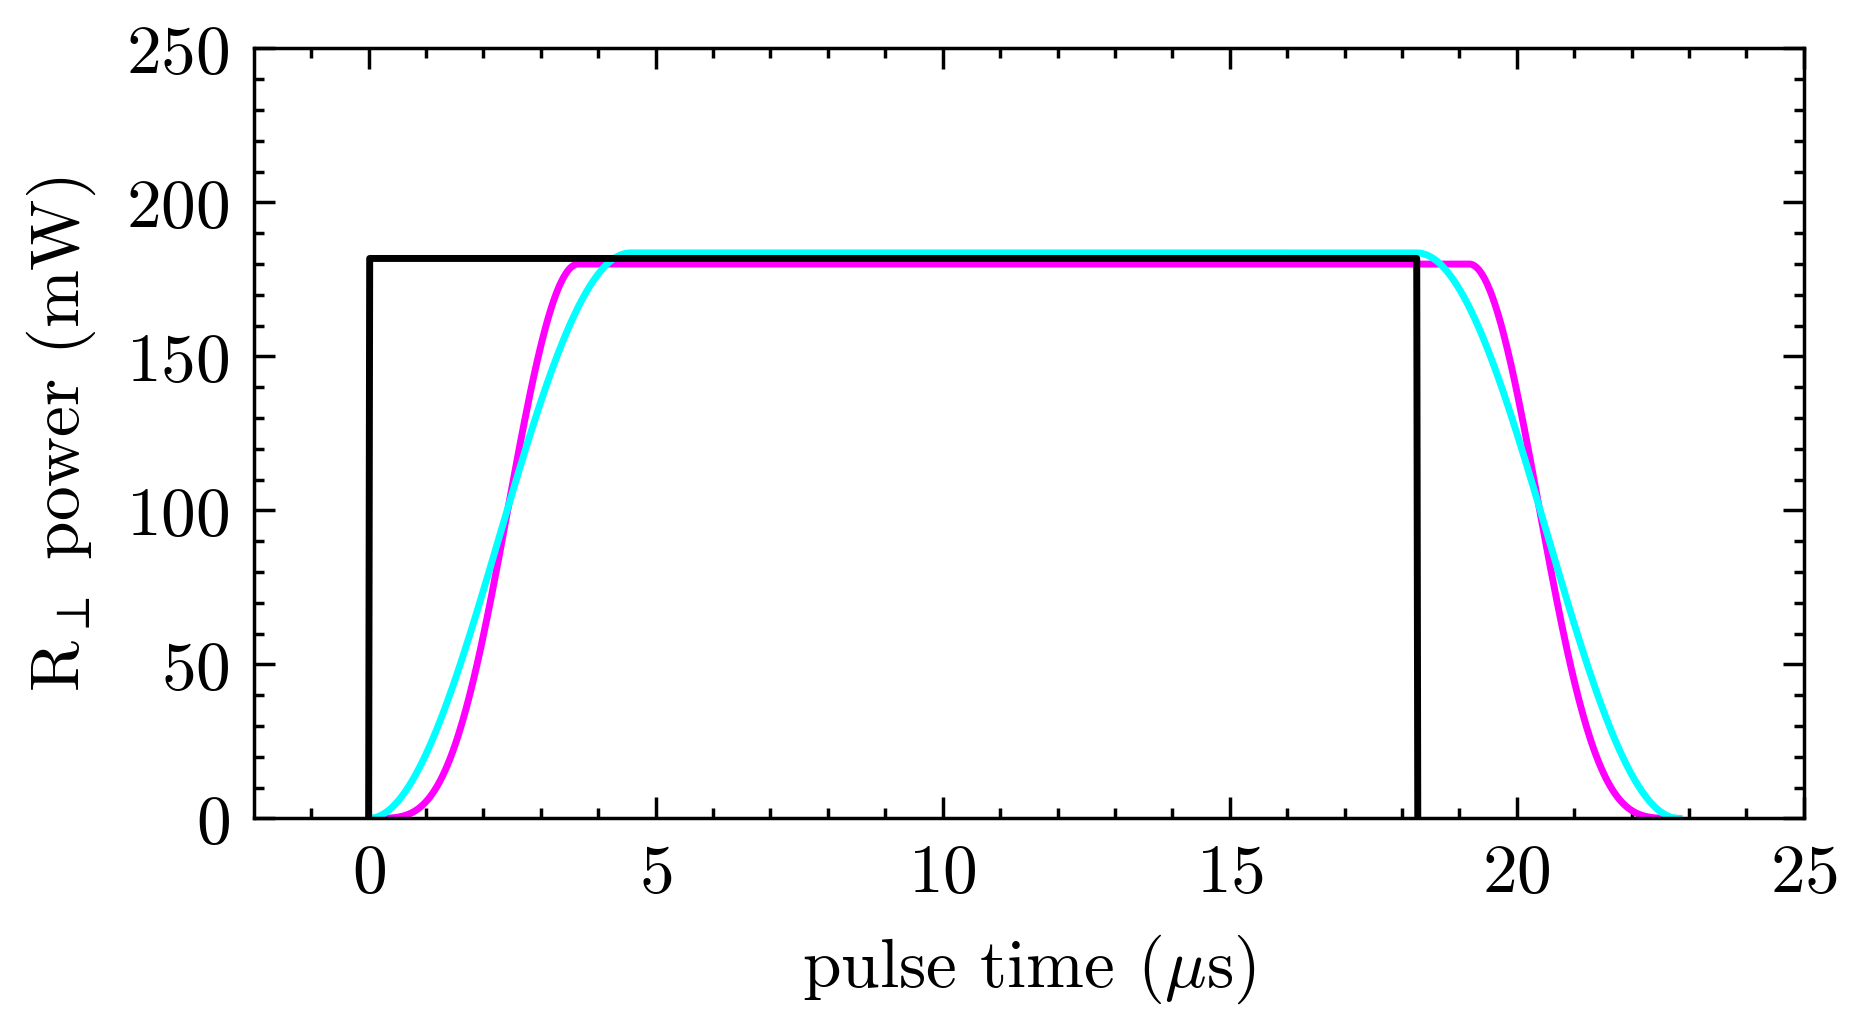

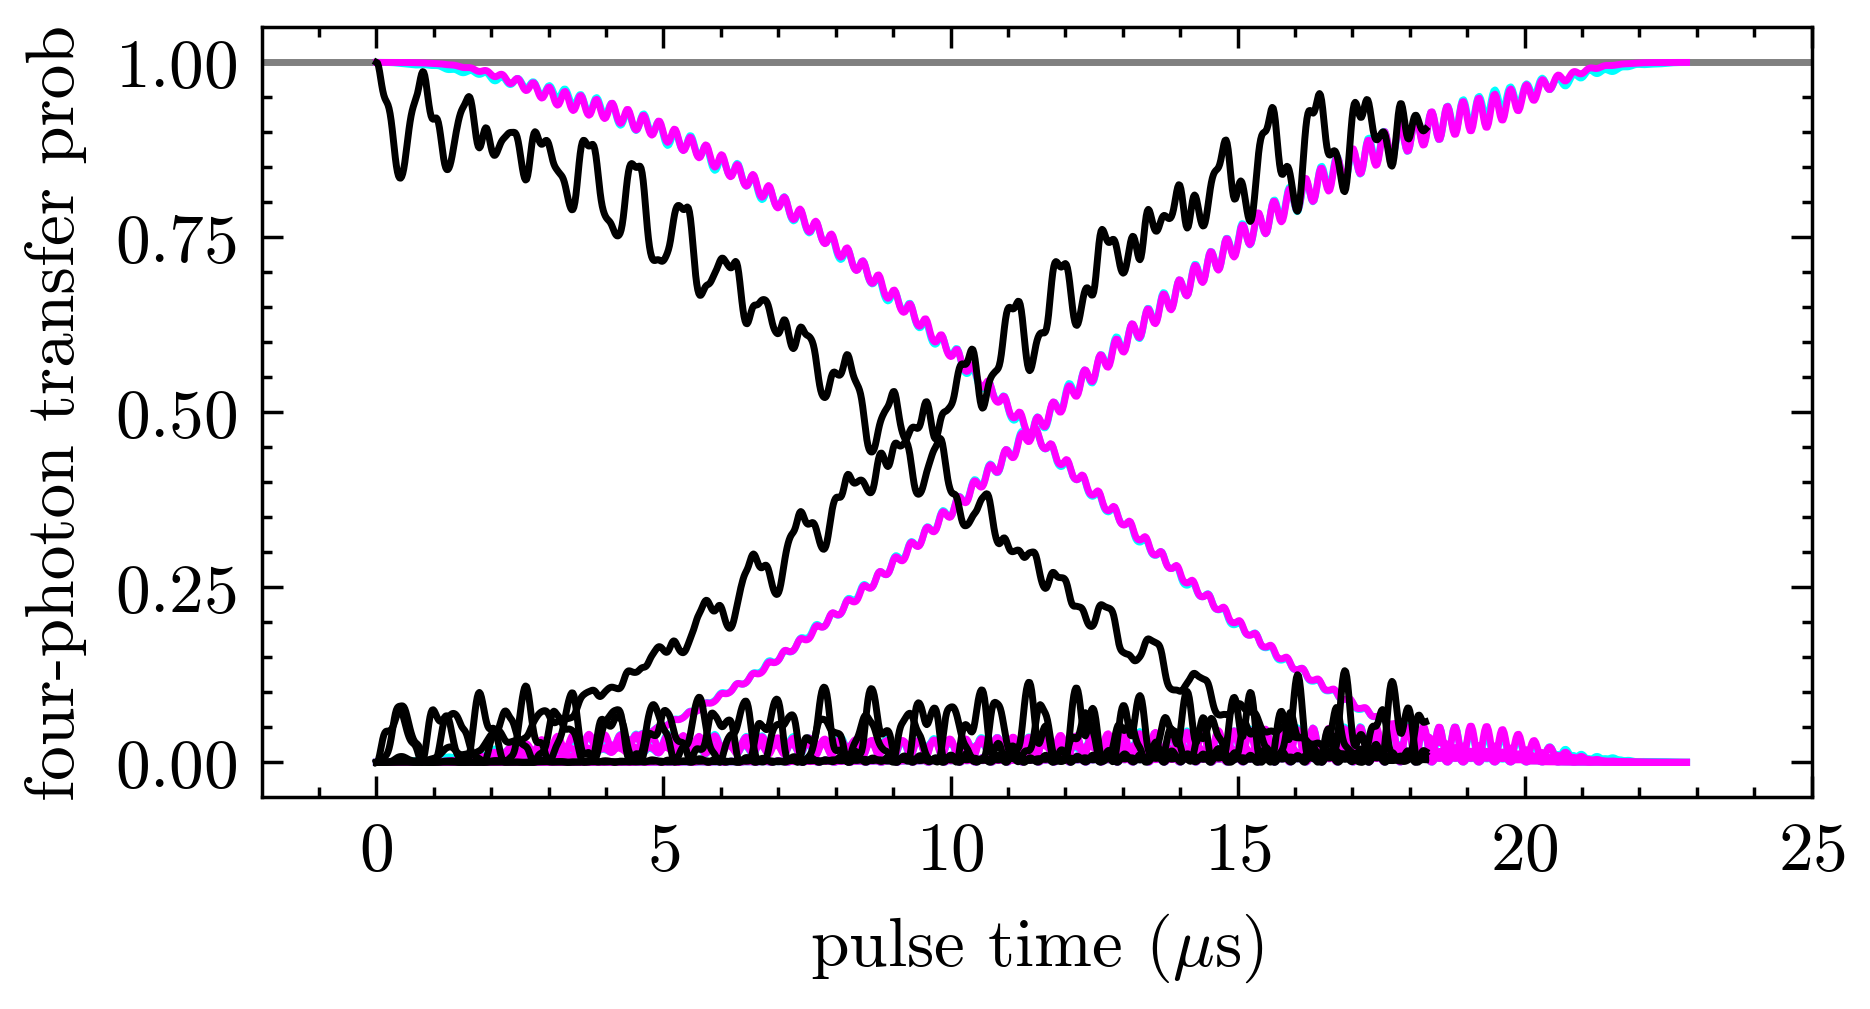

In [11]:
with plt.style.context(['science','no-latex']):
    
    ind1 = -1
    ind3 = 0
    
    plt.figure(dpi = 500, figsize = (4,2))
    
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.env_bank[ind1]*sim2.Pb*1e3, color = 'magenta')
    plt.plot(sim.t_bank[ind1]*1e6, sim.env_bank[ind1]*sim.Pb*1e3*1.02, color = 'cyan')
    plt.plot(sim.t_bank[ind3]*1e6, sim.env_bank[ind3]*sim.Pb*1e3*1.01, color = 'black')
    
    plt.ylabel(r'R$_\perp$ power (mW)')
    plt.xlabel(r'pulse time ($\mu$s)')
    plt.xlim(-2,25)
    plt.ylim(0,250)
    plt.show()
    
    plt.figure(dpi = 500, figsize = (4,2))
    
    plt.axhline(1, color = 'grey')

    plt.ylabel(r'four-photon transfer prob')
    plt.xlabel(r'pulse time ($\mu$s)')
    
    plt.plot(sim.t_bank[ind1]*1e6, sim.p52_bank[ind1], color = 'cyan')
    plt.plot(sim.t_bank[ind1]*1e6, sim.p32_bank[ind1], color = 'cyan')
    plt.plot(sim.t_bank[ind1]*1e6, sim.p12_bank[ind1], color = 'cyan')
    plt.plot(sim.t_bank[ind1]*1e6, sim.m12_bank[ind1], color = 'cyan')
    plt.plot(sim.t_bank[ind1]*1e6, sim.m32_bank[ind1], color = 'cyan')
    plt.plot(sim.t_bank[ind1]*1e6, sim.m52_bank[ind1], color = 'cyan')
    
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.p52_bank[ind1], color = 'magenta')
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.p32_bank[ind1], color = 'magenta')
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.p12_bank[ind1], color = 'magenta')
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.m12_bank[ind1], color = 'magenta')
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.m32_bank[ind1], color = 'magenta')
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.m52_bank[ind1], color = 'magenta')
    
    plt.plot(sim.t_bank[ind3]*1e6, sim.p52_bank[ind3], color = 'black')
    plt.plot(sim.t_bank[ind3]*1e6, sim.p32_bank[ind3], color = 'black')
    plt.plot(sim.t_bank[ind3]*1e6, sim.p12_bank[ind3], color = 'black')
    plt.plot(sim.t_bank[ind3]*1e6, sim.m12_bank[ind3], color = 'black')
    plt.plot(sim.t_bank[ind3]*1e6, sim.m32_bank[ind3], color = 'black')
    plt.plot(sim.t_bank[ind3]*1e6, sim.m52_bank[ind3], color = 'black')
    plt.xlim(-2,25)
    plt.show()

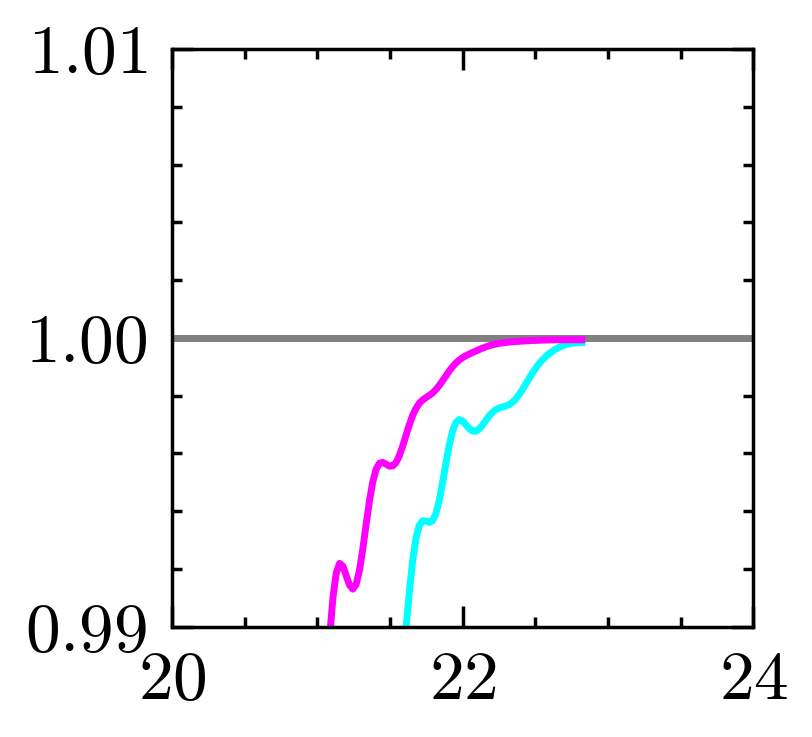

In [9]:
with plt.style.context(['science','no-latex']):
    plt.figure(dpi = 500, figsize = (1.5,1.5))
    
    plt.axhline(1, color = 'grey')

    plt.plot(sim.t_bank[ind1]*1e6, sim.p52_bank[ind1], color = 'cyan')
    plt.plot(sim.t_bank[ind1]*1e6, sim.p32_bank[ind1], color = 'cyan')
    plt.plot(sim.t_bank[ind1]*1e6, sim.p12_bank[ind1], color = 'cyan')
    plt.plot(sim.t_bank[ind1]*1e6, sim.m12_bank[ind1], color = 'cyan')
    plt.plot(sim.t_bank[ind1]*1e6, sim.m32_bank[ind1], color = 'cyan')
    plt.plot(sim.t_bank[ind1]*1e6, sim.m52_bank[ind1], color = 'cyan')
    
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.p52_bank[ind1], color = 'magenta')
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.p32_bank[ind1], color = 'magenta')
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.p12_bank[ind1], color = 'magenta')
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.m12_bank[ind1], color = 'magenta')
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.m32_bank[ind1], color = 'magenta')
    plt.plot(sim2.t_bank[ind1]*1e6, sim2.m52_bank[ind1], color = 'magenta')

    plt.xlim(20,24)
    plt.ylim(.99,1.01)
    plt.show()

In [10]:
ω = sim2.ω

dt = 1e-9
t = np.arange(-150e-6, 200e-6 + dt, dt)
f =  (1 + np.cos(ω*t))

ps = np.interp(t, sim.t_bank[ind3], (sim.env_bank[ind3]**.5))*f
ps2 = np.interp(t, sim.t_bank[ind1], (sim.env_bank[ind1]**.5))*f
ps4 = np.interp(t, sim2.t_bank[ind1], (sim2.env_bank[ind1]**.5))*f


def get_spectrum(t, pulse):
    X = np.fft.fftshift(np.fft.fft(pulse)) * dt
    f = np.fft.fftshift(np.fft.fftfreq(len(t), d=dt))
    spectrum = np.abs(X)
    spectrum /= spectrum.max() if spectrum.max() != 0 else 1.0
    
    return f, spectrum


f, spectrum = get_spectrum(t, ps)
f2, spectrum_2 = get_spectrum(t, ps2)
f4, spectrum_4 = get_spectrum(t, ps4)


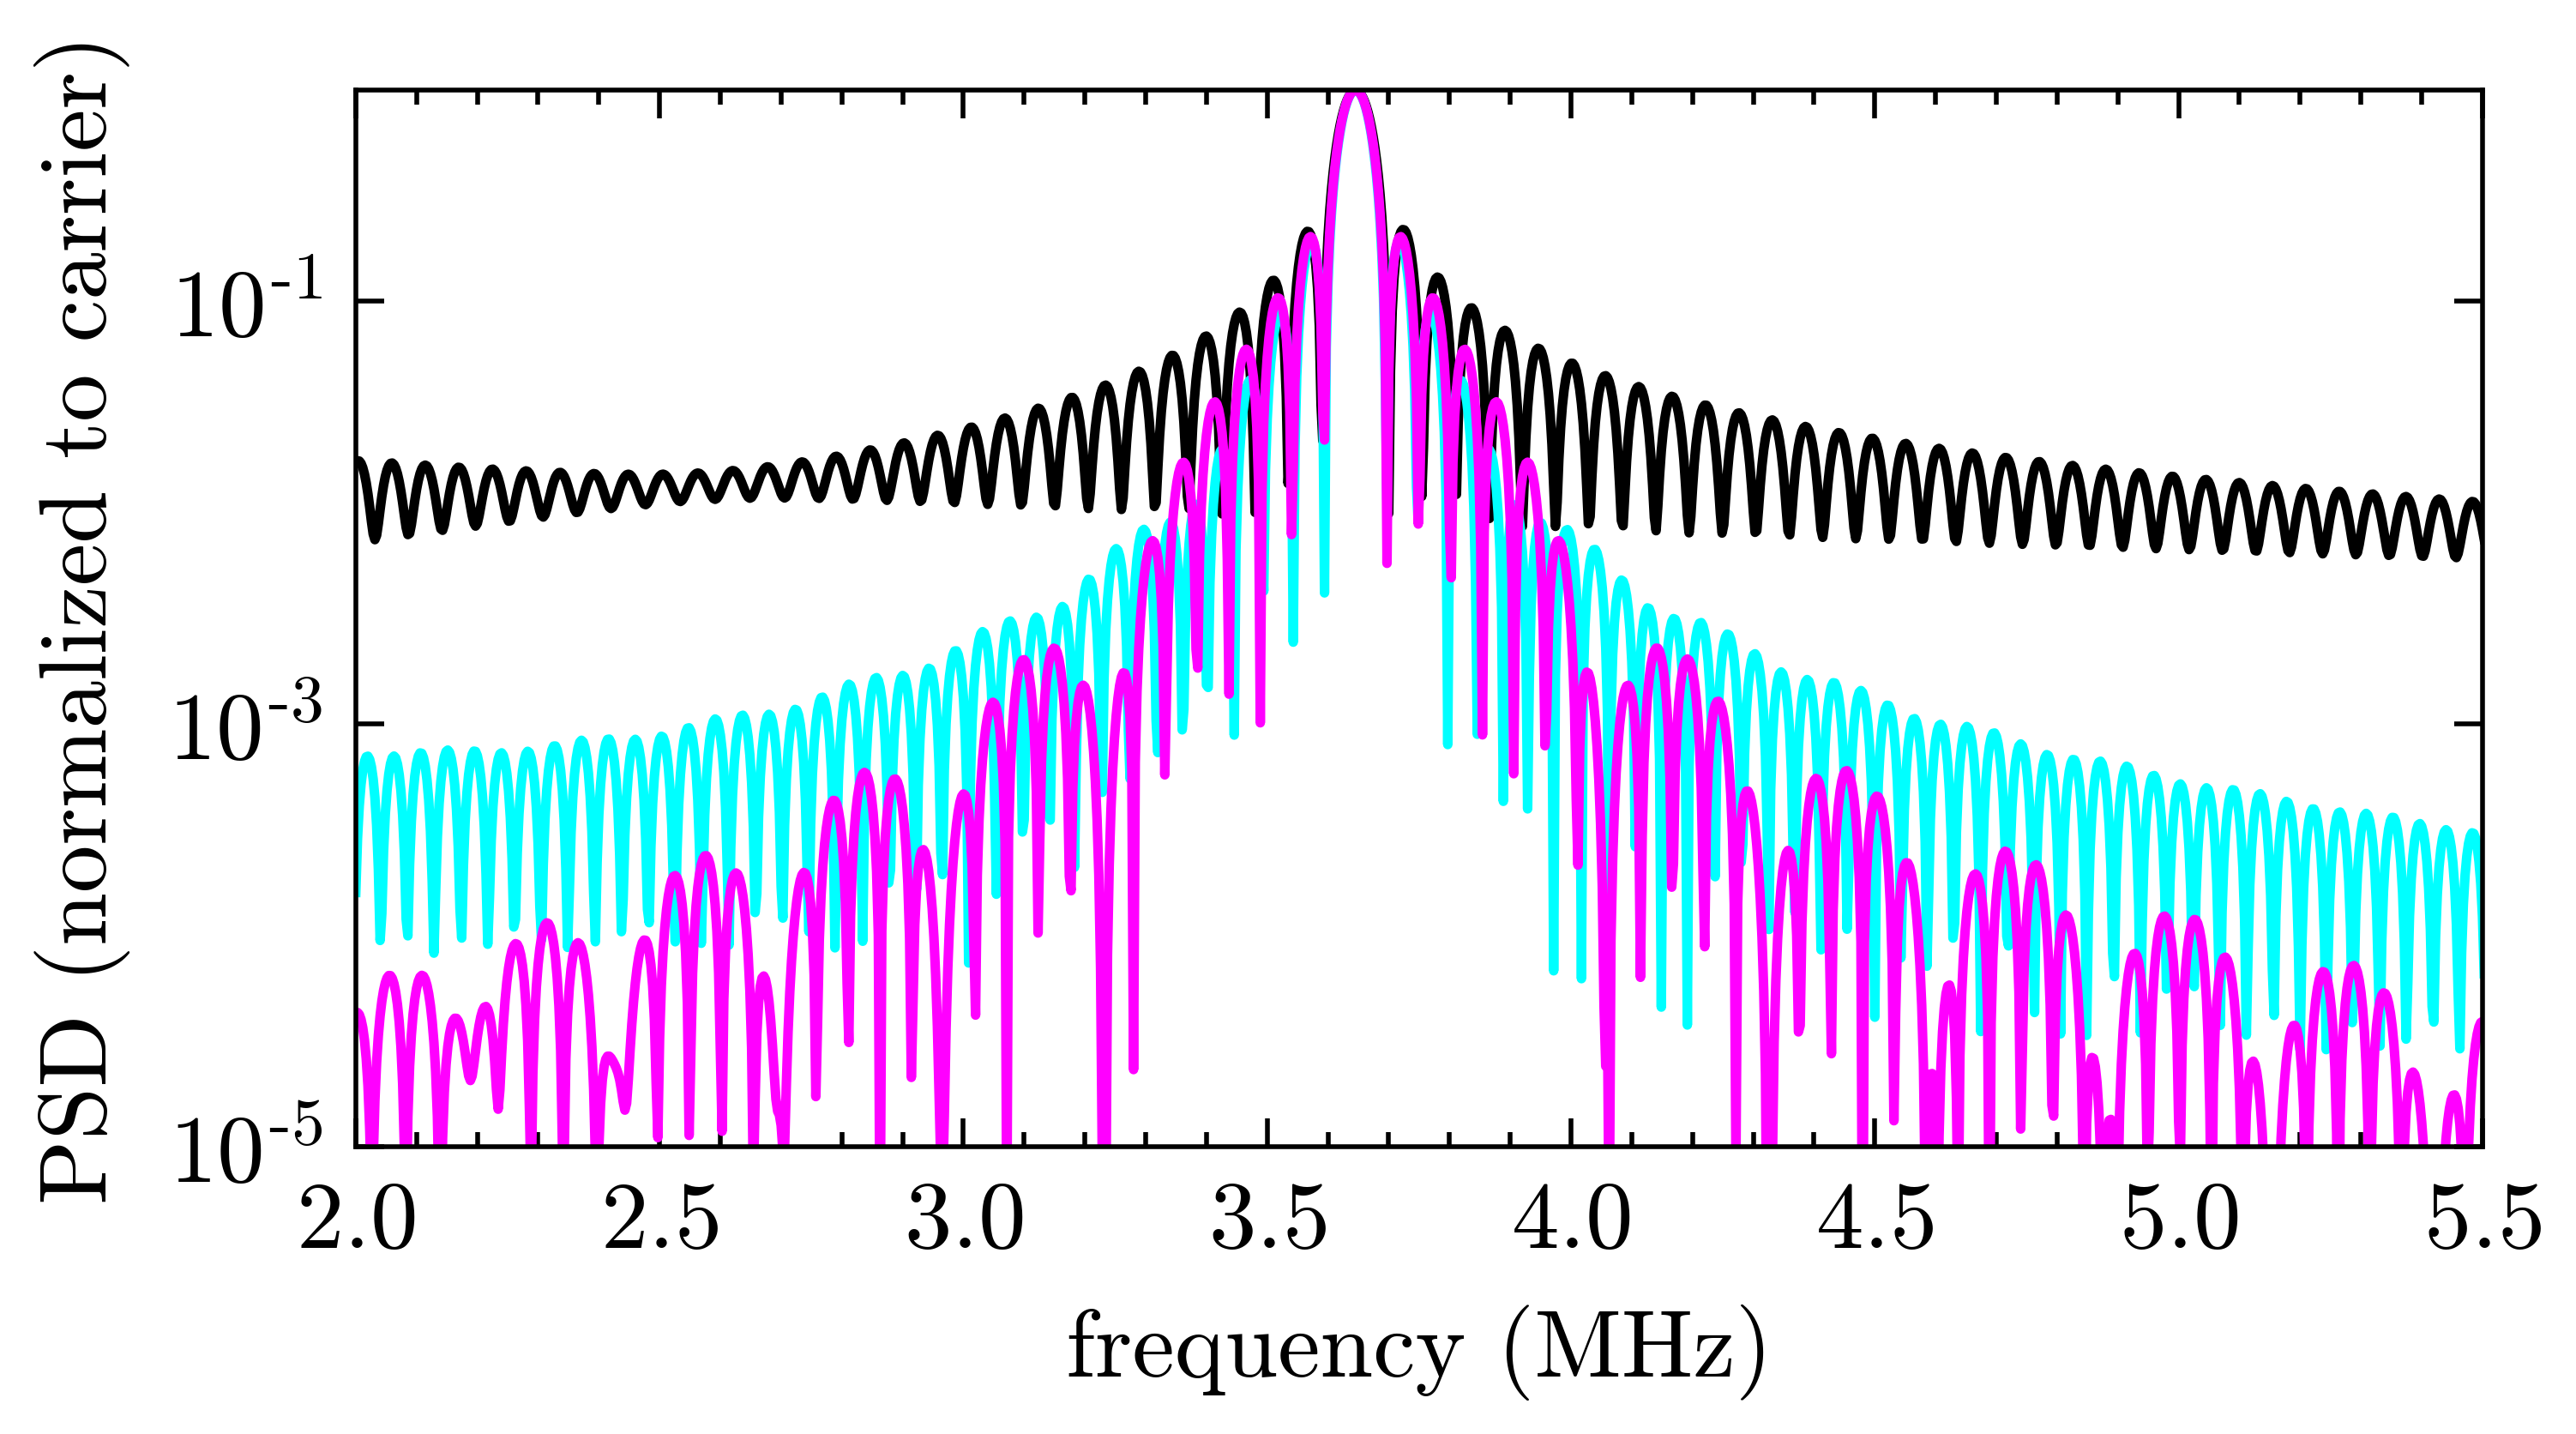

In [11]:
x = np.linspace(2, 5.5,100)*1e6

Ω0 = np.pi/(18.8e-6)
Ω = (2*2*np.pi*2.2e6*Ω0)**.35

y_test = Ω/(((2*Ω**2) + (x - 3.7e6)**2)**.5)

with plt.style.context(['science','no-latex']):
    plt.figure(dpi = 800, figsize = (4,2))
    plt.plot(f*1e-6, spectrum*2, color = 'black')
    plt.plot(f*1e-6, spectrum_2*2, color = 'cyan')
    plt.plot(f*1e-6, spectrum_4*2, color = 'magenta')
    plt.xlim(2, 5.5)
    plt.yscale('log')
    plt.ylim(1e-5, 1)
    plt.xlabel('frequency (MHz)')
    plt.ylabel('PSD (normalized to carrier)')
    
    plt.show()